# validate flows trained for different binary combo
Generate validation figure for the paper

In [1]:
import os
import numpy as np 

from noah2 import data as D
from causalflow import causalflow

In [2]:
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [3]:
##################################################################
# read CRS participant data
DNoah = D.Noah2()
fema = DNoah._read_data_full()
is_participant = DNoah._participants(fema)
fema = fema[is_participant]

metro = ((fema['RUCA1'] == 1))# | (fema['RUCA1'] == 2) | (fema['RUCA1'] == 3))
micro = ((fema['RUCA1'] == 4) | (fema['RUCA1'] == 5) | (fema['RUCA1'] == 6))
small = ((fema['RUCA1'] == 7) | (fema['RUCA1'] == 8) | (fema['RUCA1'] == 9))
rural = ((fema['RUCA1'] == 10))
arch_dict = {'metro': metro, 'micro': micro, 'small': small, 'rural': rural}    

columns = DNoah._columns()[:8] + ['s_%s' % c for c in ['c350', 'c420', 'c450']]
column_labels = np.array(DNoah._column_labels()[:8] + ['c350', 'c420', 'c450'])

# binary activity codes
binary_activities = ['c360', 'c520', 'c530', 'c540', 'c610', 'c620', 'c630']

binary_data = np.array([np.array(fema[col]) for col in binary_activities]).T
binary_data = (binary_data > 0).astype(int)

binary_act_codes = np.zeros(len(fema)).astype(int)
for i in range(binary_data.shape[1]):
    binary_act_codes += 2**i * binary_data[:,i]

# compile training data
_data = np.array([np.array(fema[col]) for col in columns]).T
# reduce dynamical range
_data[:,0] = np.log10(_data[:,0])
_data[:,3] = np.log10(_data[:,3])
_data[:,4] = np.log10(_data[:,4])

In [4]:
def uncode(num): 
    act = np.zeros(len(binary_activities)).astype(int)
    while num > 0: 
        ind = int(np.floor(np.log(num)/np.log(2)))
        num = num - 2**ind
        act[ind] = 1
    return act

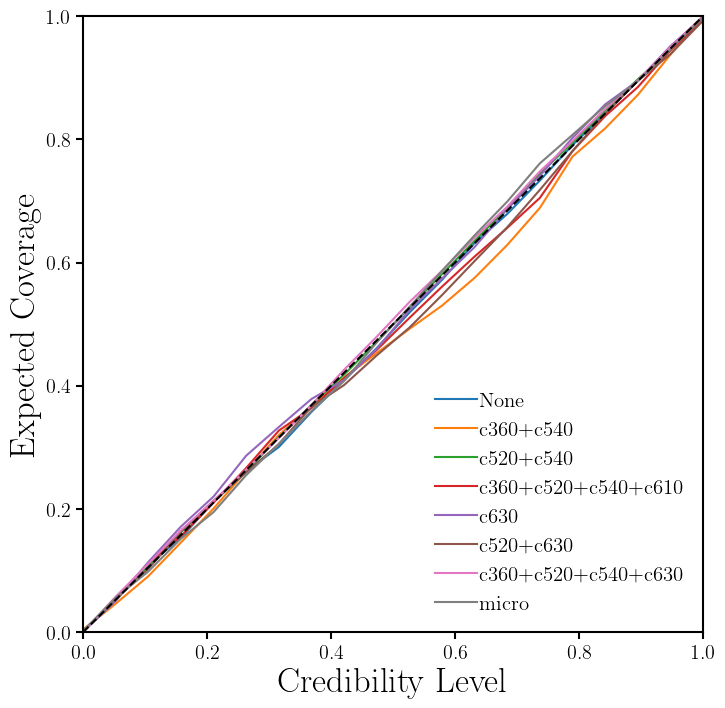

In [5]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)

arch = 'metro'
for i, code in enumerate([0, 9, 10, 27, 64, 66, 75]):
    # only keep data of specified archetype that performs set of binary activities
    test_data = _data[arch_dict[arch] & (binary_act_codes == code)]

    Ntrain = int(test_data.shape[0] * 0.9)

    # shufftle training data
    ishfl = np.arange(test_data.shape[0])
    np.random.seed(42)
    np.random.shuffle(ishfl)
    test_data = test_data[ishfl][Ntrain:] # reserve 10% for testing

    # load flows     
    Cflow = causalflow.CausalFlowA()
    flows = Cflow._load_flows_optuna('%s.%i' % (arch, code), '/scratch/gpfs/chhahn/noah/noah2/qphi/')
    
    alpha_lin = np.linspace(0., 1., 20)
    ecps_lin = []
    for ii in range(11):
        alpha, ecp = Cflow._validate(flows, test_data[:,1:], test_data[:,0][:,None], 
                                     Nsample=10000, verbose=False)
        ecps_lin.append(np.interp(alpha_lin, alpha, ecp))
    
    if code == 0: lbl = 'None'
    else: lbl = '+'.join(list(np.array(binary_activities)[np.array(uncode(code)).astype(bool)]))
        
    ax.plot(alpha_lin, np.median(np.array(ecps_lin), axis=0), color='C%i' % i, label=lbl)

i += 1
arch = 'micro'
for _i, code in enumerate([0]):
    # only keep data of specified archetype that performs set of binary activities
    test_data = _data[arch_dict[arch] & (binary_act_codes == code)]

    Ntrain = int(test_data.shape[0] * 0.9)

    # shufftle training data
    ishfl = np.arange(test_data.shape[0])
    np.random.seed(42)
    np.random.shuffle(ishfl)
    test_data = test_data[ishfl][Ntrain:] # reserve 10% for testing

    # load flows     
    Cflow = causalflow.CausalFlowA()
    flows = Cflow._load_flows_optuna('%s.%i' % (arch, code), '/scratch/gpfs/chhahn/noah/noah2/qphi/')
    
    alpha_lin = np.linspace(0., 1., 20)
    ecps_lin = []
    for ii in range(11):
        alpha, ecp = Cflow._validate(flows, test_data[:,1:], test_data[:,0][:,None], 
                                     Nsample=10000, verbose=False)
        ecps_lin.append(np.interp(alpha_lin, alpha, ecp))

    ax.plot(alpha_lin, np.median(np.array(ecps_lin), axis=0), color='C%i' % i, 
            label=arch+' '+'+'.join(list(np.array(binary_activities)[np.array(uncode(code)).astype(bool)])))    
    i += 1
            
ax.plot([0, 1], [0, 1], ls="--", color="k")

ax.legend(loc='lower right', handletextpad=0.1, fontsize=15)
ax.set_ylabel("Expected Coverage", fontsize=25)
ax.set_ylim(0., 1.)
ax.set_xlabel("Credibility Level", fontsize=25)
ax.set_xlim(0., 1.)
fig.savefig('flow_valid.pdf', bbox_inches='tight')